In [3]:
# let's see the original node counts for each dataset

import json
import os
import pandas as pd

original_root_pth = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/ctc_format/scaled_ctc/'
ds_summary = pd.read_csv(f'{original_root_pth}/summary.csv')

ds_names = []
fp_nodes = []
fn_nodes = []
ctc_fp_nodes = []
ctc_fn_nodes = []
ctc_ns_nodes = []
for row in ds_summary.itertuples():
    ds = row.ds_name
    basic_metrics_pth = f'{original_root_pth}/{ds}/basic_metrics.zarr/traccuracy-results.json'
    with open(basic_metrics_pth, 'r') as f:
        metrics = json.load(f)['traccuracy'][0]['results']
    ds_names.append(ds)
    fp_nodes.append(metrics['False Positive Nodes'])
    fn_nodes.append(metrics['False Negative Nodes'])

    ctc_metrics_pth = f'{original_root_pth}/{ds}/matched_solution.zarr/traccuracy-results.json'
    with open(ctc_metrics_pth, 'r') as f:
        metrics = json.load(f)['traccuracy'][0]['results']
    ctc_fp_nodes.append(metrics['fp_nodes'])
    ctc_fn_nodes.append(metrics['fn_nodes'])
    ctc_ns_nodes.append(metrics['ns_nodes'])

original_node_counts = pd.DataFrame({
    'ds_name': ds_names,
    'og_fp_nodes': fp_nodes,
    'og_fn_nodes': fn_nodes,
    'og_ctc_fp_nodes': ctc_fp_nodes,
    'og_ctc_fn_nodes': ctc_fn_nodes,
    'og_ctc_ns_nodes': ctc_ns_nodes,
})

kit_root = '/home/ddon0001/PhD/experiments/kit-ge'
kit_fp_nodes = []
kit_fn_nodes = []
kit_ctc_fp_nodes = []
kit_ctc_fn_nodes = []
kit_ctc_ns_nodes = []
for row in ds_summary.itertuples():
    ds = row.ds_name
    ds, seq = ds.split('_')
    basic_metrics_pth = f'{kit_root}/{ds}/{seq}_basic.zarr/traccuracy-results.json'
    with open(basic_metrics_pth, 'r') as f:
        metrics = json.load(f)['traccuracy'][0]['results']
        kit_fp_nodes.append(metrics['False Positive Nodes'])
        kit_fn_nodes.append(metrics['False Negative Nodes'])

    ctc_metrics_pth = f'{kit_root}/{ds}/{seq}_ctc.zarr/traccuracy-results.json'
    with open(ctc_metrics_pth, 'r') as f:
        metrics = json.load(f)['traccuracy'][0]['results']
    kit_ctc_fp_nodes.append(metrics['fp_nodes'])
    kit_ctc_fn_nodes.append(metrics['fn_nodes'])
    kit_ctc_ns_nodes.append(metrics['ns_nodes'])

    ctc_metrics_pth
original_node_counts['kit_fp_nodes'] = kit_fp_nodes
original_node_counts['kit_fn_nodes'] = kit_fn_nodes
original_node_counts['kit_ctc_fp_nodes'] = kit_ctc_fp_nodes
original_node_counts['kit_ctc_fn_nodes'] = kit_ctc_fn_nodes
original_node_counts['kit_ctc_ns_nodes'] = kit_ctc_ns_nodes

ultrack_root = '/home/ddon0001/PhD/experiments/ultrack'
ultrack_fp_nodes = []
ultrack_fn_nodes = []
ultrack_ctc_fp_nodes = []
ultrack_ctc_fn_nodes = []
ultrack_ctc_ns_nodes = []
for row in ds_summary.itertuples():
    ds = row.ds_name
    ds, seq = ds.split('_')
    basic_metrics_pth = f'{ultrack_root}/{ds}_{seq}_default_basic.zarr/traccuracy-results.json'
    if not os.path.exists(basic_metrics_pth):
        ultrack_fp_nodes.append(-1)
        ultrack_fn_nodes.append(-1)
    else:
        with open(basic_metrics_pth, 'r') as f:
            metrics = json.load(f)['traccuracy'][0]['results']
            ultrack_fp_nodes.append(metrics['False Positive Nodes'])
            ultrack_fn_nodes.append(metrics['False Negative Nodes'])

    ctc_metrics_pth = f'{ultrack_root}/{ds}_{seq}_default_ctc.zarr/traccuracy-results.json'
    if not os.path.exists(ctc_metrics_pth):
        ultrack_ctc_fp_nodes.append(-1)
        ultrack_ctc_fn_nodes.append(-1)
        ultrack_ctc_ns_nodes.append(-1)
    else:
        with open(ctc_metrics_pth, 'r') as f:
            metrics = json.load(f)['traccuracy'][0]['results']
        ultrack_ctc_fp_nodes.append(metrics['fp_nodes'])
        ultrack_ctc_fn_nodes.append(metrics['fn_nodes'])
        ultrack_ctc_ns_nodes.append(metrics['ns_nodes'])
original_node_counts['ultrack_default_fp_nodes'] = ultrack_fp_nodes
original_node_counts['ultrack_default_fn_nodes'] = ultrack_fn_nodes
original_node_counts['ultrack_default_ctc_fp_nodes'] = ultrack_ctc_fp_nodes
original_node_counts['ultrack_default_ctc_fn_nodes'] = ultrack_ctc_fn_nodes
original_node_counts['ultrack_default_ctc_ns_nodes'] = ultrack_ctc_ns_nodes

ultrack_custom_fp_nodes = []
ultrack_custom_fn_nodes = []
ultrack_custom_ctc_fp_nodes = []
ultrack_custom_ctc_fn_nodes = []
ultrack_custom_ctc_ns_nodes = []
for row in ds_summary.itertuples():
    ds = row.ds_name
    ds, seq = ds.split('_')
    basic_metrics_pth = f'{ultrack_root}/{ds}_{seq}_custom_basic.zarr/traccuracy-results.json'
    if not os.path.exists(basic_metrics_pth):
        ultrack_custom_fp_nodes.append(-1)
        ultrack_custom_fn_nodes.append(-1)
    else:
        with open(basic_metrics_pth, 'r') as f:
            metrics = json.load(f)['traccuracy'][0]['results']
            ultrack_custom_fp_nodes.append(metrics['False Positive Nodes'])
            ultrack_custom_fn_nodes.append(metrics['False Negative Nodes'])

    ctc_metrics_pth = f'{ultrack_root}/{ds}_{seq}_custom_ctc.zarr/traccuracy-results.json'
    if not os.path.exists(ctc_metrics_pth):
        ultrack_custom_ctc_fp_nodes.append(-1)
        ultrack_custom_ctc_fn_nodes.append(-1)
        ultrack_custom_ctc_ns_nodes.append(-1)
    else:
        with open(ctc_metrics_pth, 'r') as f:
            metrics = json.load(f)['traccuracy'][0]['results']
        ultrack_custom_ctc_fp_nodes.append(metrics['fp_nodes'])
        ultrack_custom_ctc_fn_nodes.append(metrics['fn_nodes'])
        ultrack_custom_ctc_ns_nodes.append(metrics['ns_nodes'])
original_node_counts['ultrack_custom_fp_nodes'] = ultrack_custom_fp_nodes
original_node_counts['ultrack_custom_fn_nodes'] = ultrack_custom_fn_nodes
original_node_counts['ultrack_custom_ctc_fp_nodes'] = ultrack_custom_ctc_fp_nodes
original_node_counts['ultrack_custom_ctc_fn_nodes'] = ultrack_custom_ctc_fn_nodes
original_node_counts['ultrack_custom_ctc_ns_nodes'] = ultrack_custom_ctc_ns_nodes

original_node_counts.sort_values(by='ds_name')

,ds_name,og_fp_nodes,og_fn_nodes,og_ctc_fp_nodes,og_ctc_fn_nodes,og_ctc_ns_nodes,kit_fp_nodes,kit_fn_nodes,kit_ctc_fp_nodes,kit_ctc_fn_nodes,...,ultrack_default_fp_nodes,ultrack_default_fn_nodes,ultrack_default_ctc_fp_nodes,ultrack_default_ctc_fn_nodes,ultrack_default_ctc_ns_nodes,ultrack_custom_fp_nodes,ultrack_custom_fn_nodes,ultrack_custom_ctc_fp_nodes,ultrack_custom_ctc_fn_nodes,ultrack_custom_ctc_ns_nodes
20,BF-C2DL-HSC_01,0,1,0,1,0,212,0,213,1,...,0,28,0,3,25,0,29,0,3,26
21,BF-C2DL-HSC_02,0,2,0,2,0,2041,78,2061,21,...,0,111,0,19,92,0,86,0,9,77
18,BF-C2DL-MuSC_01,0,23,0,23,0,33,32,36,22,...,0,187,0,75,104,0,185,0,78,100
19,BF-C2DL-MuSC_02,0,72,0,72,0,50,48,53,37,...,0,174,0,98,72,0,218,0,131,83
14,DIC-C2DH-HeLa_01,0,16,0,16,0,14,15,14,13,...,0,149,0,132,17,0,34,0,27,7
15,DIC-C2DH-HeLa_02,0,42,0,42,0,1,51,5,40,...,0,104,0,89,13,0,53,0,51,2
10,Fluo-C2DL-MSC_01,0,1,0,1,0,12,0,12,0,...,1,57,1,57,0,1,4,1,4,0
11,Fluo-C2DL-MSC_02,0,0,0,0,0,11,1,12,1,...,0,17,0,17,0,0,17,0,17,0
30,Fluo-C3DH-A549-SIM_01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31,Fluo-C3DH-A549-SIM_02,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
original_node_counts[[
    'ds_name',
    'ultrack_fn_nodes',
    'ultrack_fp_nodes'
]].sort_values(by='ds_name')

KeyError: "['ultrack_fn_nodes', 'ultrack_fp_nodes'] not in index"

In [5]:
original_node_counts['ultrack_default_fn_delta'] = original_node_counts['ultrack_default_fn_nodes'] - original_node_counts['og_fn_nodes']
original_node_counts['ultrack_custom_fn_delta'] = original_node_counts['ultrack_custom_fn_nodes'] - original_node_counts['og_fn_nodes']
original_node_counts['kit_fn_delta'] = original_node_counts['kit_fn_nodes'] - original_node_counts['og_fn_nodes']

original_node_counts['ultrack_default_fp_delta'] = original_node_counts['ultrack_default_fp_nodes'] - original_node_counts['og_fp_nodes']
original_node_counts['ultrack_custom_fp_delta'] = original_node_counts['ultrack_custom_fp_nodes'] - original_node_counts['og_fp_nodes']
original_node_counts['kit_fp_delta'] = original_node_counts['kit_fp_nodes'] - original_node_counts['og_fp_nodes']

original_node_counts['ultrack_default_ctc_fn_delta'] = original_node_counts['ultrack_default_ctc_fn_nodes'] - original_node_counts['og_ctc_fn_nodes']
original_node_counts['ultrack_custom_ctc_fn_delta'] = original_node_counts['ultrack_custom_ctc_fn_nodes'] - original_node_counts['og_ctc_fn_nodes']
original_node_counts['kit_ctc_fn_delta'] = original_node_counts['kit_ctc_fn_nodes'] - original_node_counts['og_ctc_fn_nodes']

original_node_counts['ultrack_default_ctc_fp_delta'] = original_node_counts['ultrack_default_ctc_fp_nodes'] - original_node_counts['og_ctc_fp_nodes']
original_node_counts['ultrack_custom_ctc_fp_delta'] = original_node_counts['ultrack_custom_ctc_fp_nodes'] - original_node_counts['og_ctc_fp_nodes']
original_node_counts['kit_ctc_fp_delta'] = original_node_counts['kit_ctc_fp_nodes'] - original_node_counts['og_ctc_fp_nodes']

original_node_counts['ultrack_default_ctc_ns_delta'] = original_node_counts['ultrack_default_ctc_ns_nodes'] - original_node_counts['og_ctc_ns_nodes']
original_node_counts['ultrack_custom_ctc_ns_delta'] = original_node_counts['ultrack_custom_ctc_ns_nodes'] - original_node_counts['og_ctc_ns_nodes']
original_node_counts['kit_ctc_ns_delta'] = original_node_counts['kit_ctc_ns_nodes'] - original_node_counts['og_ctc_ns_nodes']

In [6]:
original_node_counts.to_csv('./kit_ultrack_custom_and_default_node_deltas.csv')

In [7]:
deltas = original_node_counts[original_node_counts.og_fn_nodes >= 0][[
    'ds_name',
    'ultrack_default_fn_delta',
    'ultrack_custom_fn_delta',
    'kit_fn_delta',
    'ultrack_default_fp_delta',
    'ultrack_custom_fp_delta',
    'kit_fp_delta',
    'ultrack_default_ctc_fn_delta',
    'ultrack_custom_ctc_fn_delta',
    'kit_ctc_fn_delta',
    'ultrack_default_ctc_fp_delta',
    'ultrack_custom_ctc_fp_delta',
    'kit_ctc_fp_delta',
    'ultrack_default_ctc_ns_delta',
    'ultrack_custom_ctc_ns_delta',
    'kit_ctc_ns_delta'
]]
deltas

,ds_name,ultrack_default_fn_delta,ultrack_custom_fn_delta,kit_fn_delta,ultrack_default_fp_delta,ultrack_custom_fp_delta,kit_fp_delta,ultrack_default_ctc_fn_delta,ultrack_custom_ctc_fn_delta,kit_ctc_fn_delta,ultrack_default_ctc_fp_delta,ultrack_custom_ctc_fp_delta,kit_ctc_fp_delta,ultrack_default_ctc_ns_delta,ultrack_custom_ctc_ns_delta,kit_ctc_ns_delta
0,Fluo-N3DH-SIM+_01,1,2,0,0,0,0,1,1,0,0,0,0,0,1,0
1,Fluo-N3DH-SIM+_02,13,7,0,0,0,0,13,7,0,0,0,0,0,0,0
2,Fluo-C3DL-MDA231_01,21,6,-1,0,0,5,19,5,-1,0,0,7,2,1,2
3,Fluo-C3DL-MDA231_02,17,9,4,0,1,9,10,2,1,0,1,10,7,7,4
4,Fluo-N2DH-GOWT1_01,6,2,-1,0,0,0,6,2,-1,0,0,0,0,0,0
5,Fluo-N2DH-GOWT1_02,10,6,-2,0,0,3,10,6,-2,0,0,3,0,0,0
6,PhC-C2DH-U373_01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,PhC-C2DH-U373_02,15,14,0,0,0,37,1,0,0,0,0,37,14,14,0
8,Fluo-N2DL-HeLa_01,42,33,-4,0,2,58,27,20,-3,0,2,62,15,13,3
9,Fluo-N2DL-HeLa_02,118,65,-4,1,1,208,71,27,-9,1,1,213,46,38,10


In [20]:
error_map = {
    "fn_delta": "fn",
    "fp_delta": "fp",
    "ctc_fn_delta": "ctc_fn",
    "ctc_fp_delta": "ctc_fp",
    "ctc_ns_delta": "ctc_ns",
}

long = deltas.melt(
    id_vars="ds_name",
    var_name="col",
    value_name="delta",
)

long["method"] = long["col"].str.extract(r"^(ultrack_default|ultrack_custom|kit)")
long["method"] = long["method"].str.replace("kit", "kit-ge")
long["error_type"] = long["col"].str.replace(r"^(ultrack_default_|ultrack_custom_|kit_)", "", regex=True)
long["error_type"] = long["error_type"].map(error_map)

ctc_errors = [
    "ctc_fn",
    "ctc_fp",
    "ctc_ns",
]

df_ctc = long[long["error_type"].isin(ctc_errors)]
df_other = long[~long["error_type"].isin(ctc_errors)]

In [9]:
ds_summary = pd.read_csv('/home/ddon0001/PhD/experiments/scaled/pre-thesis/scaled_w_merge/summary.csv')
ds_order = ds_summary.sort_values(by='total_det', ascending=False)['ds_name'].tolist()

In [21]:
# palette = {
#     "fn": "#023481",
#     "fp": "#0388D6",
#     "ctc_fn": "#8A5572",
#     "ctc_fp": "#4D2D3E",
#     "ctc_ns": "#EF89C0",
# }
import seaborn as sns

markers = {
    "fn": "o",
    "fp": "X",
    "ctc_fn": "o",
    "ctc_fp": "X",
    "ctc_ns": "^",
}

def plot_grid(long):
    y_map = {"ultrack_custom": 0, "ultrack_default": 0.05, "kit-ge": 0.1}
    long["y"] = long["method"].map(y_map)

    g = sns.FacetGrid(
        long,
        col="ds_name",
        col_wrap=4,
        col_order=ds_order,
        sharex=False,
        sharey=True,
        height=1.5,
        aspect=2,
    )

    g.map_dataframe(
        sns.scatterplot,
        x="delta",
        y="y",
        hue="error_type",
        style="error_type",
        palette=sns.color_palette('colorblind'),
        markers=markers,
        s=70,
        # jitter=0.15,
    )

    for ax in g.axes.flat:
        xmax = max(abs(v) for v in ax.get_xlim())
        ax.set_xlim(-xmax, xmax)
        ax.set_ylim(-0.02, 0.12)
        ax.axvline(0, color="lightgrey", lw=1)
        ax.set_yticks([0, 0.05, 0.1])
        ax.set_yticklabels(["ultrack_custom", "ultrack_default", "kit-ge"])
        ax.set_ylabel("")
        ax.set_xlabel("")

    g.tight_layout()
    g.add_legend(ncol=4)
    # g._legend.set_ncols(len(g._legend.texts))
    g._legend.set_bbox_to_anchor((0.7, 0.0001))
    g._legend.set_loc("lower right")
    # g.set_axis_labels("Δ count", "")
    g.figure.text(0.4, 0.00001, 'Δ count', ha='center', va='center', fontsize=12)  # X-axis label at the bottom center
    # g.figure.supxlabel('Δ count', fontsize=12)  # X-axis label at the bottom center
    g.figure.text(0.01, 0.5, 'method', ha='center', va='center', rotation='vertical', fontsize=12)  # Y-axis label on the left center
    # g.figure.supylabel('method', fontsize=12)  # Y-axis label on the left center

/tmp/ipykernel_38364/2866569934.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long["y"] = long["method"].map(y_map)
/home/ddon0001/miniconda3/envs/tracktour/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/ddon0001/miniconda3/envs/tracktour/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/ddon0001/miniconda3/envs/tracktour/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (3), which may not be inten

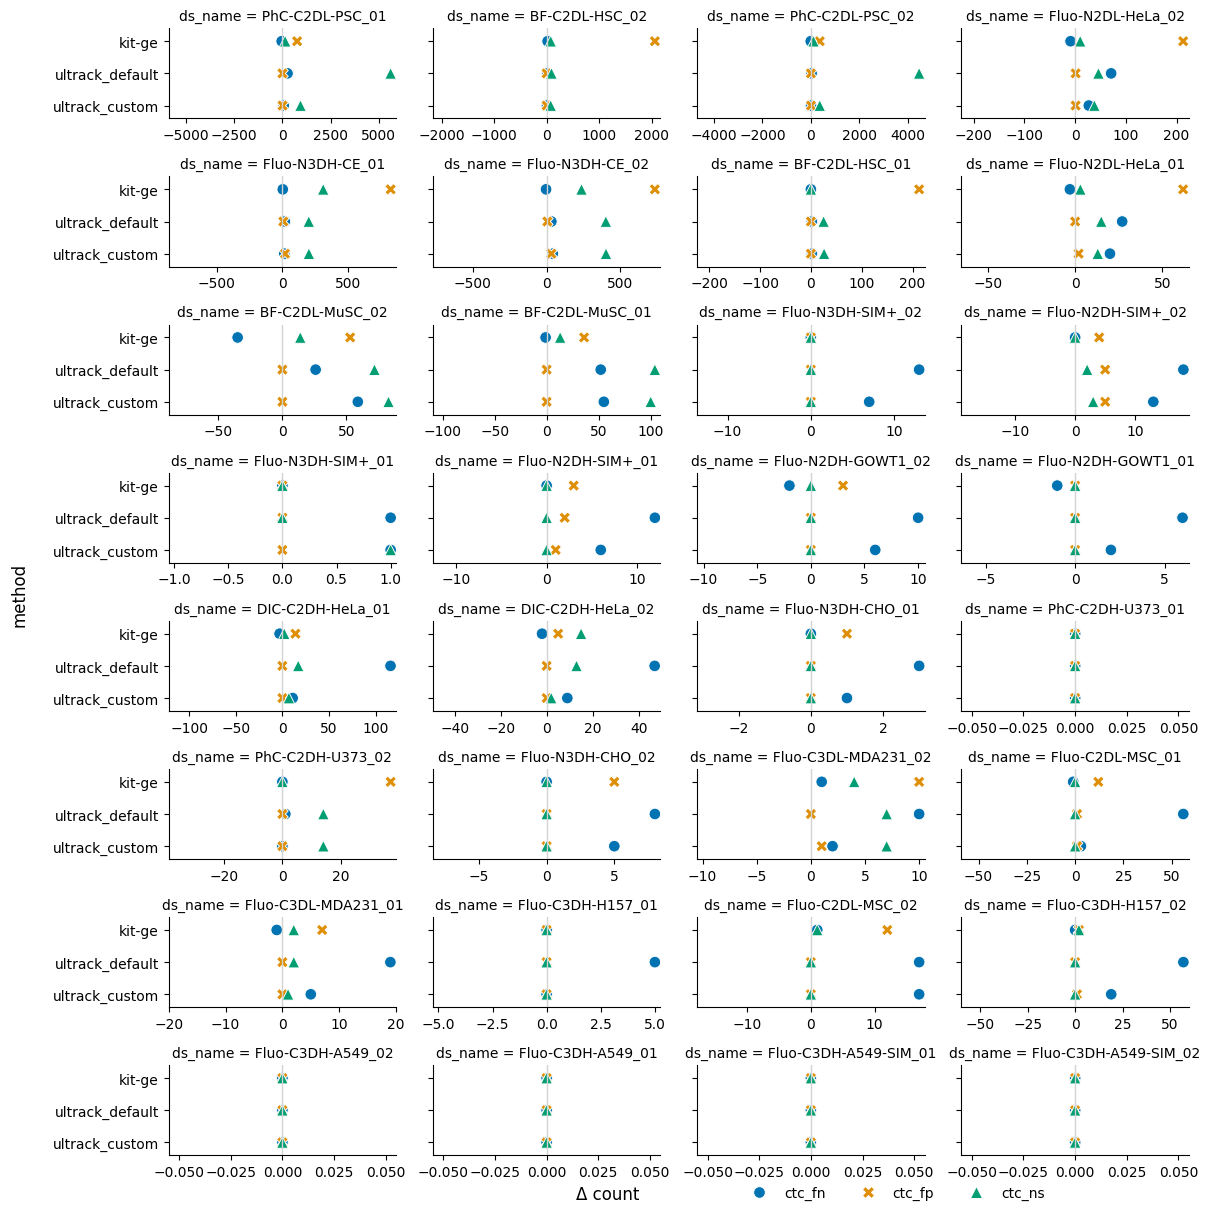

In [22]:
plot_grid(df_ctc)

/tmp/ipykernel_38364/2866569934.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long["y"] = long["method"].map(y_map)
/home/ddon0001/miniconda3/envs/tracktour/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/ddon0001/miniconda3/envs/tracktour/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/ddon0001/miniconda3/envs/tracktour/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be inten

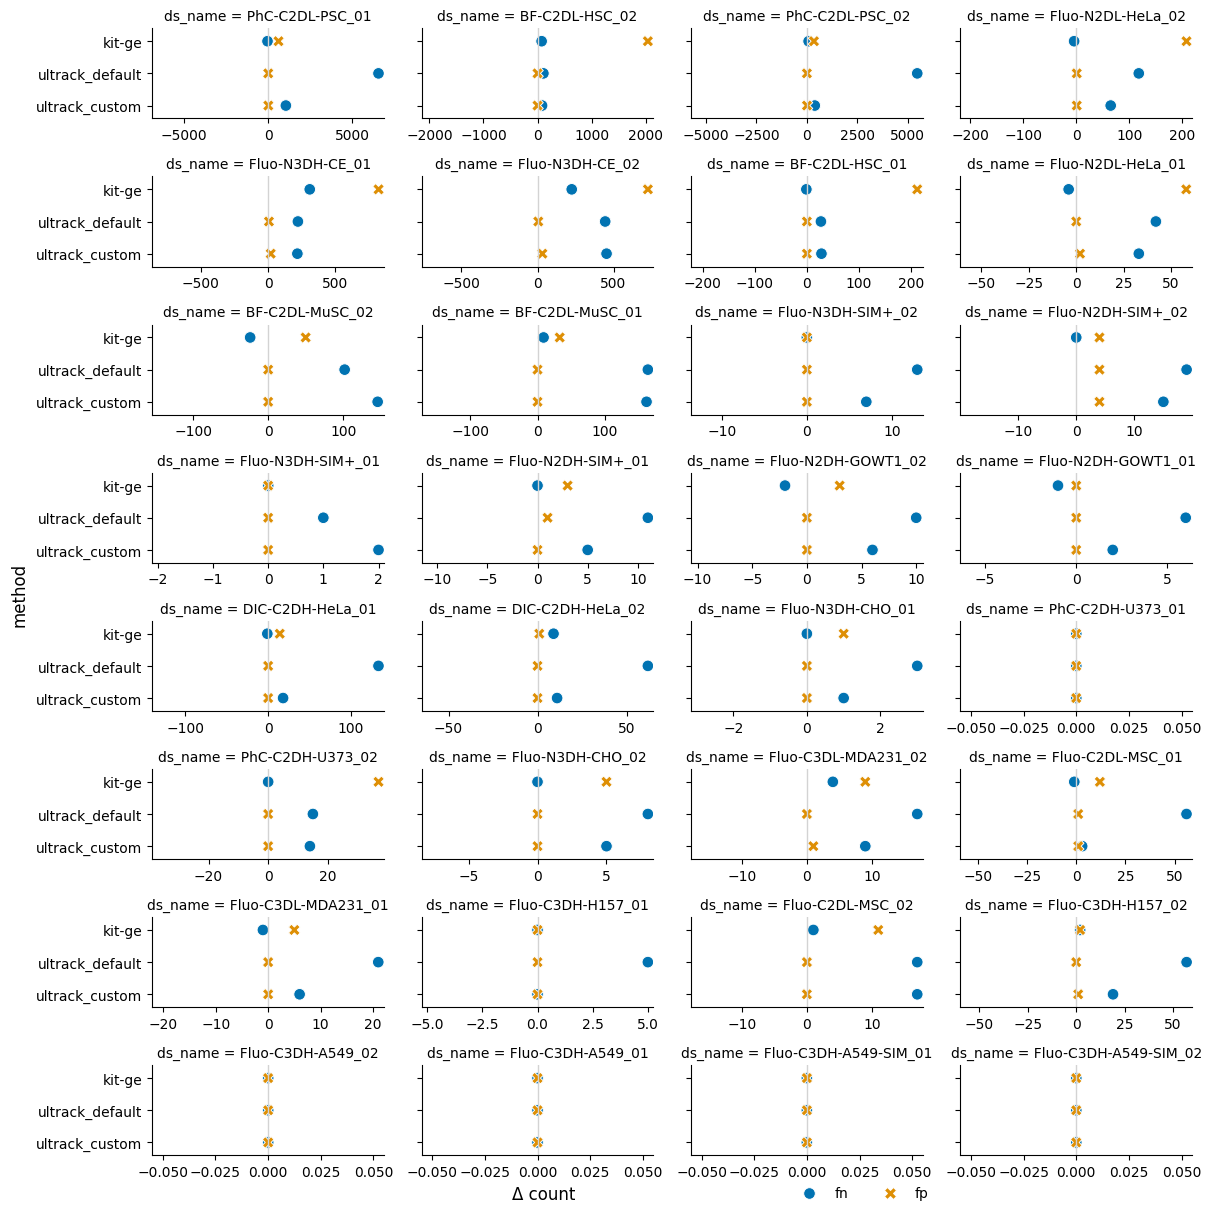

In [23]:
plot_grid(df_other)

We first run ultrack with its suggested config from the docs. Everything is kept to default parameters, except `segmentation_config.min_frontier=0.5`. Six datasets fail to solve, as listed below.

```
{('Fluo-C2DL-MSC',
  '02_ERR_SEG'): 'No links found for time 0. Increase `linking_config.max_distance` parameter.',
 ('BF-C2DL-MuSC',
  '02_ERR_SEG'): 'No links found for time 188. Increase `linking_config.max_distance` parameter.',
 ('BF-C2DL-MuSC',
  '01_ERR_SEG'): 'No links found for time 221. Increase `linking_config.max_distance` parameter.',
 ('BF-C2DL-HSC',
  '01_ERR_SEG'): 'No links found for time 104. Increase `linking_config.max_distance` parameter.',
 ('Fluo-N3DH-CE',
  '02_ERR_SEG'): 'No links found for time 3. Increase `linking_config.max_distance` parameter.',
 ('Fluo-N3DH-CE',
  '01_ERR_SEG'): 'No links found for time 4. Increase `linking_config.max_distance` parameter.'}
```

When we look at ctc evaluation, we see there's not a lot of FP nodes (splitting segments), but we've introduced a lot of new FN and NS nodes. This implies we're likely merging segments too zealously. We try running ultrack again, this time relaxing any parameters that may lead to improper merging of segments, guided by [the docs](https://royerlab.github.io/ultrack/optimizing.html#tracking-tuning). Specifically:

```python
segmentation_config.min_frontier = 0.0
segmentation_config.min_area = 20
linking_config.max_distance = 50
linking_config.max_neighbors = 10
```